# ATLANTIS for Relation Extraction — Qwen2 (Decoder-Only)

Mirrors the Flan-T5 notebook but adapts ATLANTIS for a **decoder-only** causal LM.

**Recommended run order** — validate pipeline cheaply before committing to full runs:
1. `RUN_SIZE = "small"`  → Qwen2-0.5B / 1.5B — fast sanity check (~10 min/epoch)
2. `RUN_SIZE = "medium"` → Qwen2-1.5B / 7B  — intermediate validation (~30 min/epoch)
3. `RUN_SIZE = "full"`   → Qwen2-0.5B / 7B  — paper-scale experiment

Key architectural differences from seq2seq T5:
- Input and label **concatenated**: `[prompt tokens][label tokens][EOS]`
- `log p(y|x)` computed by masking prompt with -100, reading causal LM loss over label tokens only
- Generation slices off the prompt prefix to extract the predicted label
- Gradient accumulation matches paper's effective batch size of 16

Same ATLANTIS algorithm (Algorithm 1): weights pre-computed from frozen models before training.


## 1.1 Installation

In [1]:
!pip install -q transformers datasets scikit-learn accelerate sentencepiece bitsandbytes
print("Done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.1 MB/s eta 0:00:00
Done.


## 1.2 Imports

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM, get_linear_schedule_with_warmup
from datasets import load_dataset
from sklearn.metrics import f1_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU:   {torch.cuda.get_device_name(0)}")
    print(f"VRAM:  {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU:   NVIDIA A100-SXM4-80GB
VRAM:  85.1 GB


## 1.3 Config

In [3]:
# ── Run size — controls model pair and hyperparameters ───────────────────────
RUN_SIZE = "full"   # <-- change this to scale up

MODEL_CONFIGS = {
    "small":  {"small": "Qwen/Qwen2-0.5B", "large": "Qwen/Qwen2-1.5B"},
    "full": {"small": "Qwen/Qwen2-1.5B", "large": "Qwen/Qwen2-7B"},
}

INSTRUCT_CONFIGS = {
    "small":  "Qwen/Qwen2-0.5B-Instruct",
    "full":   "Qwen/Qwen2-1.5B-Instruct",
}

SMALL_MODEL = MODEL_CONFIGS[RUN_SIZE]["small"]
LARGE_MODEL = MODEL_CONFIGS[RUN_SIZE]["large"]
INSTRUCT_MODEL = INSTRUCT_CONFIGS[RUN_SIZE]

PR_MODE = "custom"

# ── Dataset ───────────────────────────────────────────────────────────────────
DATASET = "semeval" # conll2004

SPLIT_PR = False
SPLIT_RATIO = 0.5

# ── Training ──────────────────────────────────────────────────────────────────
MAX_INPUT_LEN  = 256   # prompt tokens — increase to 512 if truncation > 5%
MAX_TARGET_LEN = 16    # label tokens
MAX_TOTAL_LEN  = MAX_INPUT_LEN + MAX_TARGET_LEN

# Hyperparameters scaled by run size
# Paper (<=13B): batch=2, grad_accum=8 → effective=16, lr=2e-5
TRAIN_CONFIGS = {
    "small":  {"batch": 8,  "grad_accum": 2,  "lr": 2e-5, "num_epochs": 2, "pr_epochs": 2},
    "full": {"batch": 1,  "grad_accum": 16,  "lr": 2e-5, "num_epochs": 2, "pr_epochs": 2},
}

BATCH_SIZE       = TRAIN_CONFIGS[RUN_SIZE]["batch"]
GRAD_ACCUM_STEPS = TRAIN_CONFIGS[RUN_SIZE]["grad_accum"]
NUM_EPOCHS       = TRAIN_CONFIGS[RUN_SIZE]["num_epochs"]
PR_EPOCHS        = TRAIN_CONFIGS[RUN_SIZE]["pr_epochs"]
LR               = TRAIN_CONFIGS[RUN_SIZE]["lr"]
WARMUP_RATIO     = 0.2

EVAL_LOGPROB_FALLBACK = False

# ── ATLANTIS weight computation ───────────────────────────────────────────────
LOGPROB_MODE = "sum"   # "mean" removes length bias (recommended for SemEval)
                        # "sum"  theoretically correct IS, but length-biased
WEIGHT_CLIP  = 5.0

# ── Quick test ────────────────────────────────────────────────────────────────
QUICK_TEST = False

if QUICK_TEST:
    NUM_EPOCHS = 1
    PR_EPOCHS  = 2
    SUBSAMPLE  = 0.05
    print("QUICK_TEST mode: 1 epoch, 5% data")
else:
    SUBSAMPLE = 1.0
    print("Full experiment mode")

eff_batch = BATCH_SIZE * GRAD_ACCUM_STEPS
print(f"RUN_SIZE: {RUN_SIZE}")
print(f"  SMALL_MODEL: {SMALL_MODEL}")
print(f"  LARGE_MODEL: {LARGE_MODEL}")
print(f"  Batch: {BATCH_SIZE} x grad_accum {GRAD_ACCUM_STEPS} = effective {eff_batch}")
print(f"  LR: {LR}  |  NUM_EPOCHS: {NUM_EPOCHS}  |  PR_EPOCHS: {PR_EPOCHS}")
print(f"  LOGPROB_MODE: {LOGPROB_MODE!r}  |  WEIGHT_CLIP: {WEIGHT_CLIP}")

Full experiment mode
RUN_SIZE: full
  SMALL_MODEL: Qwen/Qwen2-1.5B
  LARGE_MODEL: Qwen/Qwen2-7B
  Batch: 1 x grad_accum 16 = effective 16
  LR: 2e-05  |  NUM_EPOCHS: 2  |  PR_EPOCHS: 2
  LOGPROB_MODE: 'sum'  |  WEIGHT_CLIP: 5.0


## 1.4 Dataset Loading

In [4]:
SEMEVAL_CANONICAL = [
    "Cause-Effect",        # 0, 1
    "Component-Whole",     # 2, 3
    "Content-Container",   # 4, 5
    "Entity-Destination",  # 6, 7
    "Entity-Origin",       # 8, 9
    "Instrument-Agency",   # 10, 11
    "Member-Collection",   # 12, 13
    "Message-Topic",       # 14, 15
    "Product-Producer",    # 16, 17
    "Other",               # 18
]

CONLL_RELATIONS = ["Kill", "Live_In", "Located_In", "OrgBased_In", "Work_For"]

# CoNLL04 → SemEval approximate label mapping for transfer evaluation
CONLL_TO_SEMEVAL = {
    "Work_For":    "Instrument-Agency",
    "OrgBased_In": "Entity-Origin",
    "Live_In":     "Entity-Destination",
    "Located_In":  "Component-Whole",
    "Kill":        "Cause-Effect",
}

def semeval_label_to_str(label_id):
    if label_id == 18:
        return "Other"
    return SEMEVAL_CANONICAL[label_id // 2]

def load_examples(dataset_name, subsample=1.0):
    if dataset_name == "semeval":
        raw = load_dataset("sem_eval_2010_task_8")
        label_list = SEMEVAL_CANONICAL[:]
        label_options = ", ".join(label_list)
        def to_ex(item):
            return [{
                "input_text": (
                    f"Classify the semantic relation between the marked entities "
                    f"in this sentence: {item['sentence'].strip()}\n"
                    #f"Relation choices: {label_options}"
                ),
                "label_str": semeval_label_to_str(item["relation"]),
            }]
        train = [ex for item in raw["train"] for ex in to_ex(item)]
        test  = [ex for item in raw["test"]  for ex in to_ex(item)]

    elif dataset_name == "conll2004":
        raw = load_dataset("DFKI-SLT/conll04")
        label_list = CONLL_RELATIONS[:]
        label_options = ", ".join(CONLL_RELATIONS)

        def to_ex(item):
            tokens   = item["tokens"]
            entities = item["entities"]
            sentence = " ".join(tokens)
            examples = []
            for rel in item["relations"]:
                head_ent  = entities[rel["head"]]
                tail_ent  = entities[rel["tail"]]
                head_span = " ".join(tokens[head_ent["start"]:head_ent["end"]])
                tail_span = " ".join(tokens[tail_ent["start"]:tail_ent["end"]])
                examples.append({
                    "input_text": (
                        f"Classify the relation between <e1>{head_span}</e1> and <e2>{tail_span}</e2> "
                        f"in this sentence: {sentence}\n"
                        #f"Relation choices: {label_options}"
                    ),
                    "label_str": rel["type"],
                })
            return examples

        train = [ex for item in raw["train"] for ex in to_ex(item)]
        test  = [ex for item in raw["test"]  for ex in to_ex(item)]

    else:
        raise ValueError(f"Unknown dataset: {dataset_name!r}")

    if subsample < 1.0:
        n = max(100, int(len(train) * subsample))
        train = random.sample(train, n)

    return train, test, label_list

train_all, test_examples, LABEL_LIST = load_examples(DATASET, subsample=SUBSAMPLE)
LABEL2ID = {l: i for i, l in enumerate(LABEL_LIST)}
ID2LABEL  = {i: l for l, i in LABEL2ID.items()}

print(f"Dataset:  {DATASET}")
print(f"Train:    {len(train_all)}  Test: {len(test_examples)}")
print(f"Labels ({len(LABEL_LIST)}): {LABEL_LIST}")

if DATASET == "semeval":
    raw_check = load_dataset("sem_eval_2010_task_8")
    print("\nLabel mapping verification:")
    for i, name in enumerate(raw_check["train"].features["relation"].names):
        print(f"  {i:2d}: {name:35s} → {semeval_label_to_str(i)}")

elif DATASET == "conll2004":
    from collections import Counter
    dist = Counter(ex["label_str"] for ex in train_all)
    print(f"\nAvg relations per source sentence: {len(train_all)/922:.2f}")
    print("Label distribution:")
    for label, count in dist.most_common():
        print(f"  {label:<15} {count:>4}  ({count/len(train_all):.1%})")
    print(f"\nSample input: {train_all[0]['input_text']}")
    print(f"Sample label: {train_all[0]['label_str']}")

if SPLIT_PR:
    random.shuffle(train_all)
    split_idx   = int(len(train_all) * SPLIT_RATIO)
    train_pr    = train_all[:split_idx]   # p_r sees this
    train_large = train_all[split_idx:]   # p^L_b sees this
    print(f"Split mode: p_r trains on {len(train_pr)}, p^L_b trains on {len(train_large)}")
else:
    train_pr    = train_all
    train_large = train_all

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/673k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/231k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2717 [00:00<?, ? examples/s]

Dataset:  semeval
Train:    8000  Test: 2717
Labels (10): ['Cause-Effect', 'Component-Whole', 'Content-Container', 'Entity-Destination', 'Entity-Origin', 'Instrument-Agency', 'Member-Collection', 'Message-Topic', 'Product-Producer', 'Other']

Label mapping verification:
   0: Cause-Effect(e1,e2)                 → Cause-Effect
   1: Cause-Effect(e2,e1)                 → Cause-Effect
   2: Component-Whole(e1,e2)              → Component-Whole
   3: Component-Whole(e2,e1)              → Component-Whole
   4: Content-Container(e1,e2)            → Content-Container
   5: Content-Container(e2,e1)            → Content-Container
   6: Entity-Destination(e1,e2)           → Entity-Destination
   7: Entity-Destination(e2,e1)           → Entity-Destination
   8: Entity-Origin(e1,e2)                → Entity-Origin
   9: Entity-Origin(e2,e1)                → Entity-Origin
  10: Instrument-Agency(e1,e2)            → Instrument-Agency
  11: Instrument-Agency(e2,e1)            → Instrument-Agency
  12:

## 1.5 Tokenizer

Qwen2 does not have a dedicated pad token — we set `pad_token = eos_token`.
For training we right-pad (mask out padding with -100 on labels).
For generation we left-pad so the model attends to the full prompt.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(SMALL_MODEL, trust_remote_code=True)

# Qwen2 has no pad token by default — required for batched ops
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"Tokenizer: {SMALL_MODEL}")
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"EOS token: {tokenizer.eos_token!r} (id={tokenizer.eos_token_id})")
print(f"PAD token: {tokenizer.pad_token!r} (id={tokenizer.pad_token_id})")

# Verify label tokenization — labels must tokenize to short sequences
print("\nLabel token counts:")
for label in LABEL_LIST:
    toks = tokenizer(label, add_special_tokens=False)["input_ids"]
    print(f"  {label:<25} {len(toks)} tokens: {toks}")

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: Qwen/Qwen2-1.5B
Vocab size: 151643
EOS token: '<|endoftext|>' (id=151643)
PAD token: '<|endoftext|>' (id=151643)

Label token counts:
  Cause-Effect              3 tokens: [60912, 12, 7738]
  Component-Whole           3 tokens: [2189, 12, 90582]
  Content-Container         3 tokens: [2762, 12, 4502]
  Entity-Destination        3 tokens: [3030, 9420, 20646]
  Entity-Origin             2 tokens: [3030, 51636]
  Instrument-Agency         3 tokens: [56324, 6691, 21640]
  Member-Collection         3 tokens: [9366, 12, 6482]
  Message-Topic             3 tokens: [2052, 12, 26406]
  Product-Producer          3 tokens: [4816, 12, 45008]
  Other                     1 tokens: [11409]


In [6]:
# ── Check input lengths before training ──────────────────────────────────────
# If >5% truncated, increase MAX_INPUT_LEN to 512 (costs ~2GB VRAM on 7B)
print("Checking input token lengths...")
lengths = [
    len(tokenizer(ex["input_text"], add_special_tokens=True)["input_ids"])
    for ex in train_all
]
pct_truncated = np.mean([l > MAX_INPUT_LEN for l in lengths])

print(f"  Max:    {max(lengths)} tokens")
print(f"  Mean:   {np.mean(lengths):.0f} tokens")
print(f"  Median: {int(np.median(lengths))} tokens")
print(f"  % > {MAX_INPUT_LEN} (truncated): {pct_truncated:.1%}")

if pct_truncated > 0.05:
    print(f"  Warning: >5% truncated — consider increasing MAX_INPUT_LEN to 512")
else:
    print(f"  OK: truncation acceptable")

Checking input token lengths...
  Max:    144 tokens
  Mean:   50 tokens
  Median: 49 tokens
  % > 256 (truncated): 0.0%
  OK: truncation acceptable


## 1.6 Dataset Class & Data Loaders

For a causal LM we build a single concatenated sequence:
```
[prompt tokens] [label tokens] [EOS]
```
Labels tensor: `-100` for prompt positions (masked from loss), real token ids for label positions.

The loss is then mean NLL over label tokens only — equivalent to `log p(label | prompt)`.

In [7]:
class REDataset(Dataset):
    """Causal LM RE dataset for Qwen2.

    Builds sequences: [prompt tokens][label tokens][EOS]
    Loss computed only over label tokens (prompt positions masked with -100).
    """
    def __init__(self, examples, label_source="gold", include_weights=False):
        self.examples        = examples
        self.label_source    = label_source
        self.include_weights = include_weights

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex    = self.examples[idx]
        label = ex["label_str"] if self.label_source == "gold" else ex["weak_label"]

        prompt_ids = tokenizer(
            ex["input_text"],
            max_length=MAX_INPUT_LEN,
            truncation=True,
            add_special_tokens=True,
        )["input_ids"]

        label_ids = tokenizer(
            label,
            max_length=MAX_TARGET_LEN,
            truncation=True,
            add_special_tokens=False,
        )["input_ids"]

        label_ids = label_ids + [tokenizer.eos_token_id]

        full_ids = prompt_ids + label_ids
        n_real   = len(full_ids)   # length before padding — all real tokens including EOS

        # Pad to MAX_TOTAL_LEN
        pad_len = MAX_TOTAL_LEN - n_real
        if pad_len > 0:
            full_ids = full_ids + [tokenizer.pad_token_id] * pad_len
        else:
            full_ids = full_ids[:MAX_TOTAL_LEN]
            n_real   = MAX_TOTAL_LEN   # truncated — all positions are real

        input_ids = torch.tensor(full_ids, dtype=torch.long)

        # Build mask from n_real, not token identity — correctly attends to EOS
        attention_mask = torch.zeros(MAX_TOTAL_LEN, dtype=torch.long)
        attention_mask[:n_real] = 1

        # Labels: -100 for prompt + padding, real ids for label tokens
        n_prompt    = len(prompt_ids)
        labels      = torch.full_like(input_ids, -100)
        label_start = n_prompt
        label_end   = min(n_prompt + len(label_ids), MAX_TOTAL_LEN)
        labels[label_start:label_end] = input_ids[label_start:label_end]

        item = {
            "input_ids":      input_ids,
            "attention_mask": attention_mask,
            "labels":         labels,
            "n_prompt":       torch.tensor(n_prompt, dtype=torch.long),
        }
        if self.include_weights:
            item["weight"] = torch.tensor(ex["weight"], dtype=torch.float32)
        return item


def make_loaders(train_exs, label_source="gold", include_weights=False):
    train_ds = REDataset(train_exs, label_source=label_source,
                         include_weights=include_weights)
    test_ds  = REDataset(test_examples, label_source="gold")
    return (
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0),
        DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
    )

# Verify a few examples
ds = REDataset(train_all[:2], label_source="gold")
for item in ds:
    lbl = item["labels"].clone()
    lbl[lbl == -100] = tokenizer.pad_token_id
    decoded_label = tokenizer.decode(lbl, skip_special_tokens=True).strip()
    print(f"Label decoded from labels tensor: {decoded_label!r}")
    print(f"  Sequence length: {item['input_ids'].shape[0]}")
    print(f"  N prompt tokens: {item['n_prompt'].item()}")
    print(f"  Label token positions: {(item['labels'] != -100).sum().item()}")
    print()

print("Dataset class defined.")

Label decoded from labels tensor: 'Component-Whole'
  Sequence length: 272
  N prompt tokens: 46
  Label token positions: 4

Label decoded from labels tensor: 'Other'
  Sequence length: 272
  N prompt tokens: 46
  Label token positions: 2

Dataset class defined.


## 1.7 Core Utilities: Log-prob and Evaluation

`compute_seq_logprob` for a causal LM:
1. Build `[prompt][label][EOS]` sequence
2. Mask prompt with -100
3. Forward pass → model returns mean NLL over unmasked (label) tokens
4. Return as mean or sum depending on `LOGPROB_MODE`

In [8]:
_snap_stats = {"exact": 0, "substring": 0, "logprob": 0}


def compute_seq_logprob(model, input_text, label_str):
    """log p(label_str | input_text) for a causal LM.

    Builds [prompt][label][EOS], masks prompt with -100, reads loss over
    label tokens. Returns mean or sum per LOGPROB_MODE.
    """
    prompt_ids = tokenizer(
        input_text,
        max_length=MAX_INPUT_LEN,
        truncation=True,
        add_special_tokens=True,
        return_tensors="pt",
    )["input_ids"].to(DEVICE)

    label_ids = tokenizer(
        label_str,
        max_length=MAX_TARGET_LEN,
        truncation=True,
        add_special_tokens=False,
        return_tensors="pt",
    )["input_ids"].to(DEVICE)

    # Append EOS
    eos = torch.tensor([[tokenizer.eos_token_id]], device=DEVICE)
    label_ids_with_eos = torch.cat([label_ids, eos], dim=-1)

    full_ids = torch.cat([prompt_ids, label_ids_with_eos], dim=-1)
    n_prompt = prompt_ids.shape[1]
    n_label  = label_ids_with_eos.shape[1]

    # Labels: -100 for prompt, real ids for label+EOS
    labels = torch.full_like(full_ids, -100)
    labels[:, n_prompt:n_prompt + n_label] = label_ids_with_eos

    with torch.no_grad():
        out = model(input_ids=full_ids, labels=labels)

    # out.loss = mean NLL over non-(-100) tokens = mean NLL over label tokens
    mean_logprob = -out.loss.item()

    if LOGPROB_MODE == "sum":
        return mean_logprob * n_label
    else:
        return mean_logprob




def _snap_single(pred):
    """Exact then substring match. Returns label or None."""
    if pred in LABEL_LIST:
        return pred
    for label in LABEL_LIST:
        if label.lower() in pred.lower() or pred.lower() in label.lower():
            return label
    return None


def _logprob_snap_batch(model, input_texts):
    """Score all labels for each input, return best per input.
    One forward pass per label over all unresolved inputs.
    """
    results = [None] * len(input_texts)
    best_lp = [float("-inf")] * len(input_texts)

    for label in LABEL_LIST:
        for i, text in enumerate(input_texts):
            lp = compute_seq_logprob(model, text, label)
            if lp > best_lp[i]:
                best_lp[i] = lp
                results[i] = label
    return results


def print_snap_stats(reset=True):
    total = sum(_snap_stats.values()) or 1
    print("Label-snapping stats:")
    for tier, count in _snap_stats.items():
        print(f"  {tier:<12} {count:>5}  ({count/total:.1%})")
    if _snap_stats["logprob"] / total > 0.05:
        print("  ⚠ >5% fell through to log-prob — check generation quality")
    if reset:
        for k in _snap_stats:
            _snap_stats[k] = 0


def evaluate(model, loader):
    """Evaluate model, return (macro-F1, preds, golds).

    Generation: prompt-only input, slice off prompt from output to get label.
    Tier 1/2 (exact/substring): batched.
    Tier 3 (log-prob): per-label batched forward passes.
    """
    model.eval()
    preds, golds = [], []

    # For generation, use left-padding so the model sees the full prompt
    tokenizer.padding_side = "left"

    with torch.no_grad():
        for batch in tqdm(loader, desc="Eval", leave=False):
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            n_prompts      = batch["n_prompt"].tolist()

            # Decode gold labels from labels tensor
            lbl = batch["labels"].clone()
            lbl[lbl == -100] = tokenizer.pad_token_id
            batch_golds = [
                tokenizer.decode(l, skip_special_tokens=True).strip()
                for l in lbl
            ]

            # Generate — pass only prompt portion of each sequence
            # Reconstruct prompt-only inputs for generation
            prompt_ids_list = [
                ids[:n] for ids, n in zip(input_ids.cpu(), n_prompts)
            ]
            # Left-pad to same length for batched generate
            max_prompt_len = max(n_prompts)
            padded_prompts = torch.stack([
                torch.cat([
                    torch.full((max_prompt_len - len(p),), tokenizer.pad_token_id),
                    p
                ])
                for p in prompt_ids_list
            ]).to(DEVICE)
            prompt_mask = (padded_prompts != tokenizer.pad_token_id).long()

            gen_out = model.generate(
                input_ids=padded_prompts,
                attention_mask=prompt_mask,
                max_new_tokens=MAX_TARGET_LEN,
                num_beams=1,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

            # Slice off prompt tokens — only keep generated portion
            decoded = [
                tokenizer.decode(
                    gen_out[i][max_prompt_len:], skip_special_tokens=True
                ).strip()
                for i in range(len(n_prompts))
            ]

            # Tier 1 + 2
            batch_preds   = [None] * len(decoded)
            tier3_indices = []
            tier3_texts   = []

            decoded_inputs = [
                tokenizer.decode(ids[:n], skip_special_tokens=True)
                for ids, n in zip(input_ids.cpu(), n_prompts)
            ]

            for i, pred in enumerate(decoded):
                snapped = _snap_single(pred)
                if snapped is not None:
                    batch_preds[i] = snapped
                    _snap_stats["exact" if pred in LABEL_LIST else "substring"] += 1
                else:
                    tier3_indices.append(i)
                    tier3_texts.append(decoded_inputs[i])

            # Tier 3
            if tier3_indices:
                if EVAL_LOGPROB_FALLBACK:
                    _snap_stats["logprob"] += len(tier3_indices)
                    tier3_preds = _logprob_snap_batch(model, tier3_texts)
                    for i, pred in zip(tier3_indices, tier3_preds):
                        batch_preds[i] = pred
                else:
                    _snap_stats["logprob"] += len(tier3_indices)
                    for i in tier3_indices:
                        batch_preds[i] = LABEL_LIST[0]   # assign first label — counted as wrong if gold differs

            preds.extend(batch_preds)
            golds.extend(batch_golds)

    # Restore right-padding for training
    tokenizer.padding_side = "right"

    macro_f1 = f1_score(golds, preds, labels=LABEL_LIST, average="macro", zero_division=0)
    print_snap_stats(reset=True)
    return macro_f1, preds, golds


print("Utilities defined.")
print(f"LOGPROB_MODE={LOGPROB_MODE!r}")

Utilities defined.
LOGPROB_MODE='sum'


## 1.8 ATLANTIS Loss

In [9]:
"""def compute_per_example_ce(model, input_ids, attention_mask, labels):
    # Per-example mean CE over label tokens. Shape: (B,)
    out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

    # --- THE FIX: Shift so that tokens < n predict n ---
    shift_logits = out.logits[..., :-1, :].contiguous()
    shift_labels = labels[..., 1:].contiguous()

    B, T_minus_1, V = shift_logits.shape

    ce = nn.CrossEntropyLoss(reduction="none", ignore_index=-100)
    per_tok = ce(shift_logits.view(-1, V), shift_labels.view(-1)).view(B, T_minus_1)

    # Calculate n_tok based on the shifted labels
    n_tok = (shift_labels != -100).float().sum(dim=-1).clamp(min=1)

    return per_tok.sum(dim=-1) / n_tok   # (B,) mean CE over label tokens"""
def compute_per_example_ce(model, input_ids, attention_mask, labels):
    """Per-example mean CE in a single batched forward pass.

    Avoids materializing the full (B, T, V) logit tensor by computing
    loss token-by-token using the model's internal shift.
    """
    B = input_ids.size(0)
    per_ce = []

    # Single forward pass with reduction='none' equivalent
    # We get per-example loss by temporarily setting each example's
    # labels to -100 for all but that example
    out = model(input_ids=input_ids, attention_mask=attention_mask)

    # Apply causal shift manually
    shift_logits = out.logits[:, :-1, :].contiguous()  # (B, T-1, V)
    shift_labels = labels[:, 1:].contiguous()           # (B, T-1)

    B, T, V = shift_logits.shape
    ce = nn.CrossEntropyLoss(reduction="none", ignore_index=-100)
    per_tok = ce(
        shift_logits.view(B * T, V),
        shift_labels.view(B * T)
    ).view(B, T)  # (B, T-1)

    n_tok = (shift_labels != -100).float().sum(dim=-1).clamp(min=1)
    return per_tok.sum(dim=-1) / n_tok  # (B,)


def atlantis_loss(model, batch, mode="sft"):
    """Algorithm 1 line 6: L = mean_i(w_i * CE_i).
    Weights are pre-computed constants — never recomputed from model being trained.
    """
    input_ids      = batch["input_ids"].to(DEVICE)
    attention_mask = batch["attention_mask"].to(DEVICE)
    labels         = batch["labels"].to(DEVICE)

    if mode == "sft":
        out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        return out.loss, torch.ones(input_ids.size(0), device=DEVICE)

    weights   = batch["weight"].to(DEVICE)
    per_ce    = compute_per_example_ce(model, input_ids, attention_mask, labels)
    return (weights * per_ce).mean(), weights


print("ATLANTIS loss defined.")

ATLANTIS loss defined.


## 1.9 Model Helpers

In [10]:
def _load_model(model_name, frozen=False):
    """Load Qwen2 causal LM.

    Float16 full fine-tuning — 100GB VRAM is sufficient for 7B.
    Gradient checkpointing enabled for 7B models to reduce activation memory.
    """
    print(f"Loading {model_name}...")
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.bfloat16 if DEVICE.type == "cuda" else torch.float32,
        trust_remote_code=True,
    ).to(DEVICE)

    if frozen:
        model.eval()
        for p in model.parameters():
            p.requires_grad_(False)
    """else:
        if "7B" in model_name or "7b" in model_name:
            model.gradient_checkpointing_enable()
            print(f"  Gradient checkpointing enabled")"""

    print(f"  Parameters: {sum(p.numel() for p in model.parameters())/1e9:.2f}B")
    if DEVICE.type == "cuda":
        print(f"  VRAM after load: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    return model


def load_frozen_small_model():
    print(f"Loading p^S_b: {SMALL_MODEL} (frozen)")
    return _load_model(SMALL_MODEL, frozen=True)


def load_frozen_large_model():
    print(f"Loading p^L_b: {LARGE_MODEL} (frozen, pre-computation only)")
    return _load_model(LARGE_MODEL, frozen=True)


def compute_and_normalize_weights(examples, key="weight"):
    from scipy.special import logsumexp

    log_w = np.array([
        ex["log_pl_b"] + ex["log_pr"] - ex["log_ps_b"]
        for ex in examples
    ])

    if LOGPROB_MODE == "sum":
        log_mean_w = logsumexp(log_w) - np.log(len(log_w))
        raw = np.exp(log_w - log_mean_w)   # always assign raw
    else:
        raw = np.exp(log_w)

    # Clip before normalizing — prevents renorm from rescaling outliers back up
    p10  = np.percentile(raw, 10)
    p95  = np.percentile(raw, 95)
    raw  = np.clip(raw, a_min=1e-3, a_max=p95)
    weights = raw / raw.mean()

    for ex, w in zip(examples, weights):
        ex[key] = float(w)

    return weights


"""def compute_and_normalize_weights(examples, key="weight"):
    #Pre-compute and self-normalize ATLANTIS weights.

    Applies within-class normalization before global normalization to remove
    structural class bias in p^L_b / p^S_b for closed-label RE tasks.

    Without this, relation types that are syntactically clearer (e.g.
    Entity-Destination) receive systematically higher weights than ambiguous
    types (e.g. Message-Topic), causing the model to collapse toward
    predicting high-weight classes regardless of example quality.

    Within-class normalization preserves the within-class example ranking
    (the core ATLANTIS signal) while removing between-class bias.

    from scipy.special import logsumexp

    log_w = np.array([
        ex["log_pl_b"] + ex["log_pr"] - ex["log_ps_b"]
        for ex in examples
    ])

    if LOGPROB_MODE == "sum":
        log_mean_w = logsumexp(log_w) - np.log(len(log_w))
        raw = np.exp(log_w - log_mean_w)
    else:
        raw = np.exp(log_w)

    # Within-class normalization — normalize each relation type to mean=1
    # independently before global normalization
    labels = [ex["label_str"] if "label_str" in ex else ex.get("weak_label", "")
              for ex in examples]
    weights = np.ones_like(raw)
    for label in set(labels):
        idx = [i for i, l in enumerate(labels) if l == label]
        if len(idx) == 0:
            continue
        class_w = raw[idx]
        weights[idx] = class_w / class_w.mean()

    # Global normalization to mean=1
    weights = weights / weights.mean()

    # Optional clip then re-normalize
    if WEIGHT_CLIP is not None:
        weights = np.clip(weights, a_min=None, a_max=WEIGHT_CLIP)
        weights = weights / weights.mean()

    for ex, w in zip(examples, weights):
        ex[key] = float(w)

    return weights"""


def finetune_small_model(train_exs, tag="p_r", label_source="gold"):
    """Fine-tune Qwen2-small for PR_EPOCHS with gradient accumulation."""
    print(f"\nFine-tuning {tag} ({SMALL_MODEL}) for {PR_EPOCHS} epochs...")
    print(f"  Effective batch: {BATCH_SIZE} x {GRAD_ACCUM_STEPS} = {BATCH_SIZE * GRAD_ACCUM_STEPS}")
    model = _load_model(SMALL_MODEL)
    train_loader, _ = make_loaders(train_exs, label_source=label_source)

    opt   = torch.optim.AdamW(model.parameters(), lr=LR)
    total = (len(train_loader) // GRAD_ACCUM_STEPS) * PR_EPOCHS
    sched = get_linear_schedule_with_warmup(opt, int(total * WARMUP_RATIO), total)

    for epoch in range(PR_EPOCHS):
        model.train(); losses = []
        opt.zero_grad()

        for step, batch in enumerate(tqdm(train_loader, desc=f"  {tag} epoch {epoch+1}/{PR_EPOCHS}")):
            out = model(
                input_ids=batch["input_ids"].to(DEVICE),
                attention_mask=batch["attention_mask"].to(DEVICE),
                labels=batch["labels"].to(DEVICE),
            )
            loss = out.loss / GRAD_ACCUM_STEPS
            loss.backward()
            losses.append(out.loss.item())

            if (step + 1) % GRAD_ACCUM_STEPS == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); sched.step()
                opt.zero_grad()

        print(f"  Epoch {epoch+1}  loss={np.mean(losses):.4f}")

    model.eval()
    print(f"{tag} complete.")
    return model


def train_large_model(train_exs, label_source="gold", include_weights=False,
                      loss_mode="sft", tag=""):
    """Train fresh Qwen2-large (p_theta) with gradient accumulation.
    Effective batch = BATCH_SIZE x GRAD_ACCUM_STEPS, matching paper setup.
    """
    print(f"\n{'='*60}\n  {tag}\n{'='*60}")
    print(f"  Effective batch: {BATCH_SIZE} x {GRAD_ACCUM_STEPS} = {BATCH_SIZE * GRAD_ACCUM_STEPS}")

    train_loader, test_loader = make_loaders(
        train_exs, label_source=label_source, include_weights=include_weights,
    )

    model = _load_model(LARGE_MODEL)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total = (len(train_loader) // GRAD_ACCUM_STEPS) * NUM_EPOCHS
    sched = get_linear_schedule_with_warmup(opt, int(total * WARMUP_RATIO), total)

    history = {"train_loss": [], "eval_f1": [], "weight_stats": []}

    for epoch in range(NUM_EPOCHS):
        model.train(); losses, all_w = [], []
        opt.zero_grad()

        for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")):
            if loss_mode == "atlantis":
                input_ids      = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                labels         = batch["labels"].to(DEVICE)
                w              = batch["weight"].to(DEVICE)

                # --- THE FIX: Removed the SFT-ramp. Applying pure weights immediately. ---
                per_ce = compute_per_example_ce(model, input_ids, attention_mask, labels)
                loss   = (w * per_ce).mean()
            else:
                loss, w = atlantis_loss(model, batch, mode=loss_mode)

            (loss / GRAD_ACCUM_STEPS).backward()
            losses.append(loss.item())
            all_w.extend(w.detach().cpu().tolist())

            if (step + 1) % GRAD_ACCUM_STEPS == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); sched.step()
                opt.zero_grad()

        avg_loss = np.mean(losses)
        f1, _, _ = evaluate(model, test_loader)

        w_arr   = np.array(all_w)
        w_stats = {
            "mean": float(w_arr.mean()), "std": float(w_arr.std()),
            "min":  float(w_arr.min()),  "max": float(w_arr.max()),
            "pct_clip_high": float((w_arr >= WEIGHT_CLIP - 1e-6).mean()) if WEIGHT_CLIP else 0.0,
        }
        history["train_loss"].append(avg_loss)
        history["eval_f1"].append(f1)
        history["weight_stats"].append(w_stats)

        line = f"  Epoch {epoch+1}  loss={avg_loss:.4f}  macro-F1={f1:.4f}"
        if loss_mode == "atlantis":
            # Cleaned up logging to remove w_scale
            line += f"  w_mean={w_stats['mean']:.3f}  w_std={w_stats['std']:.3f}"
        print(line)

    history["final_f1"] = history["eval_f1"][-1]
    print(f"  -> Final F1: {history['final_f1']:.4f}")
    return history, model


def load_instruct_reference_model():
    """Load Qwen2-Instruct as frozen reference model p_r.

    Used when PR_MODE='instruct'. The instruct model has strong task priors
    from RLHF and instruction tuning, so it can serve as p_r without
    task-specific finetuning. Note: p_r / p^S_b then captures instruction
    tuning signal rather than pure task-specific learning — a methodological
    deviation from the paper.
    """
    print(f"Loading instruct reference model: {INSTRUCT_MODEL}")
    return _load_model(INSTRUCT_MODEL, frozen=True)


def get_reference_model(train_exs, tag="p_r", label_source="gold"):
    """Return reference model p_r — either finetuned or instruct depending on PR_MODE."""
    if PR_MODE == "instruct":
        return load_instruct_reference_model()
    else:
        return finetune_small_model(train_exs, tag=tag, label_source=label_source)


print("Model helpers defined.")
print(f"p_r: {PR_EPOCHS} epochs  |  p_theta: {NUM_EPOCHS} epochs")
print(f"Effective batch size: {BATCH_SIZE} x {GRAD_ACCUM_STEPS} = {BATCH_SIZE * GRAD_ACCUM_STEPS}")

Model helpers defined.
p_r: 2 epochs  |  p_theta: 2 epochs
Effective batch size: 1 x 16 = 16


---
# Part 2 — Paradigm A: Paper Replication

All models use the same full clean SemEval training set.
ATLANTIS reweights examples but has no noise to correct.

| Condition | Data | Labels | Loss |
|-----------|------|--------|------|
| SFT | Full train | Clean | Standard CE |
| ATLANTIS | Full train | Clean | Weighted CE |

## 2.1 Fine-tune p_r on Full Training Set

In [11]:
p_r_A = get_reference_model(train_pr, tag="p_r_A")


Fine-tuning p_r_A (Qwen/Qwen2-1.5B) for 2 epochs...
  Effective batch: 1 x 16 = 16
Loading Qwen/Qwen2-1.5B...


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

KeyboardInterrupt: 

## 2.2 Evaluate p_r Quality

In [12]:

_, test_loader_pr = make_loaders(test_examples, label_source="gold")
f1_pr, _, _ = evaluate(p_r_A, test_loader_pr)
print(f"p_r test F1: {f1_pr:.4f}")
print("If F1 < 0.3, increase PR_EPOCHS and retrain before computing weights.")

Eval:   0%|          | 0/340 [00:00<?, ?it/s]

Label-snapping stats:
  exact         2717  (100.0%)
  substring        0  (0.0%)
  logprob          0  (0.0%)
p_r test F1: 0.8312
If F1 < 0.3, increase PR_EPOCHS and retrain before computing weights.


## 2.3 Load p^S_b

In [13]:
p_s_b = load_frozen_small_model()

Loading p^S_b: Qwen/Qwen2-0.5B (frozen)
Loading Qwen/Qwen2-0.5B...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  Parameters: 0.49B
  VRAM after load: 2.01 GB


## 2.4 Pre-compute ATLANTIS Weights

All three log-prob terms computed from frozen models.
`p^L_b` is loaded here and unloaded after — the model trained in 2.6 is a fresh copy.

In [14]:
print(f"Pre-computing weights for {len(train_large)} examples...")
print(f"LOGPROB_MODE={LOGPROB_MODE!r}  WEIGHT_CLIP={WEIGHT_CLIP}")
print()

p_l_b_frozen = load_frozen_large_model()
train_A = [dict(ex) for ex in train_large]

for ex in tqdm(train_A, desc="Computing log-probs"):
    ex["log_pr"]   = compute_seq_logprob(p_r_A,        ex["input_text"], ex["label_str"])
    ex["log_ps_b"] = compute_seq_logprob(p_s_b,        ex["input_text"], ex["label_str"])
    ex["log_pl_b"] = compute_seq_logprob(p_l_b_frozen, ex["input_text"], ex["label_str"])

weights = compute_and_normalize_weights(train_A)

print(f"\nSample log_pr:   {train_A[0]['log_pr']:.3f}")
print(f"Sample log_ps_b: {train_A[0]['log_ps_b']:.3f}")
print(f"Sample log_pl_b: {train_A[0]['log_pl_b']:.3f}")
print()
print(f"Normalized weight mean: {weights.mean():.4f}")
print(f"Normalized weight std:  {weights.std():.4f}")
print(f"Normalized weight min:  {weights.min():.4f}")
print(f"Normalized weight max:  {weights.max():.4f}")
print()

# Class bias check
by_label = {}
for ex in train_A:
    by_label.setdefault(ex["label_str"], []).append(ex["weight"])
print("Mean weight by relation type:")
for l, ws in sorted(by_label.items(), key=lambda x: -np.mean(x[1])):
    print(f"  {l:<25} mean={np.mean(ws):.3f}  std={np.std(ws):.3f}  n={len(ws)}")
print()
print("Healthy: roughly uniform across classes. If skewed, try LOGPROB_MODE='mean'.")

Pre-computing weights for 4000 examples...
LOGPROB_MODE='sum'  WEIGHT_CLIP=3.0

Loading p^L_b: Qwen/Qwen2-1.5B (frozen, pre-computation only)
Loading Qwen/Qwen2-1.5B...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  Parameters: 1.54B
  VRAM after load: 5.10 GB


Computing log-probs:   0%|          | 0/4000 [00:00<?, ?it/s]


Sample log_pr:   -1.361
Sample log_ps_b: -21.189
Sample log_pl_b: -20.231

Normalized weight mean: 1.0000
Normalized weight std:  1.3728
Normalized weight min:  0.8358
Normalized weight max:  25.0743

Mean weight by relation type:
  Cause-Effect              mean=1.683  std=3.412  n=492
  Entity-Destination        mean=1.232  std=1.281  n=438
  Instrument-Agency         mean=0.983  std=1.530  n=275
  Product-Producer          mean=0.882  std=0.550  n=362
  Component-Whole           mean=0.849  std=0.162  n=470
  Member-Collection         mean=0.843  std=0.123  n=357
  Other                     mean=0.836  std=0.004  n=683
  Message-Topic             mean=0.836  std=0.000  n=334
  Entity-Origin             mean=0.836  std=0.000  n=329
  Content-Container         mean=0.836  std=0.000  n=260

Healthy: roughly uniform across classes. If skewed, try LOGPROB_MODE='mean'.


## 2.5 Free Frozen Models

In [15]:
del p_r_A, p_s_b, p_l_b_frozen
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"VRAM after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB")

VRAM after cleanup: 0.02 GB


## 2.6 Run Paradigm A Experiments

In [16]:
hist_A_sft, model_A_sft = train_large_model(
    train_A,
    label_source="gold",
    include_weights=False,
    loss_mode="sft",
    tag="Paradigm A — SFT baseline",
)


  Paradigm A — SFT baseline
  Effective batch: 8 x 2 = 16
Loading Qwen/Qwen2-1.5B...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  Parameters: 1.54B
  VRAM after load: 3.11 GB


Epoch 1/3:   0%|          | 0/500 [00:00<?, ?it/s]

Eval:   0%|          | 0/340 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/340 [00:00<?, ?it/s]

Label-snapping stats:
  exact         2717  (100.0%)
  substring        0  (0.0%)
  logprob          0  (0.0%)
  Epoch 2  loss=0.1026  macro-F1=0.8411


Epoch 3/3:   0%|          | 0/500 [00:00<?, ?it/s]

Eval:   0%|          | 0/340 [00:00<?, ?it/s]

Label-snapping stats:
  exact         2717  (100.0%)
  substring        0  (0.0%)
  logprob          0  (0.0%)
  Epoch 3  loss=0.0350  macro-F1=0.8497
  -> Final F1: 0.8497


In [17]:
del model_A_sft
if torch.cuda.is_available(): torch.cuda.empty_cache()

hist_A_atlantis, model_A_atlantis = train_large_model(
    train_A,
    label_source="gold",
    include_weights=True,
    loss_mode="atlantis",
    tag="Paradigm A — ATLANTIS",
)


  Paradigm A — ATLANTIS
  Effective batch: 8 x 2 = 16
Loading Qwen/Qwen2-1.5B...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  Parameters: 1.54B
  VRAM after load: 3.11 GB


Epoch 1/3:   0%|          | 0/500 [00:00<?, ?it/s]

Eval:   0%|          | 0/340 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/340 [00:00<?, ?it/s]

Label-snapping stats:
  exact         2717  (100.0%)
  substring        0  (0.0%)
  logprob          0  (0.0%)
  Epoch 2  loss=0.1181  macro-F1=0.8475  w_mean=1.000  w_std=1.373


Epoch 3/3:   0%|          | 0/500 [00:00<?, ?it/s]

Eval:   0%|          | 0/340 [00:00<?, ?it/s]

Label-snapping stats:
  exact         2717  (100.0%)
  substring        0  (0.0%)
  logprob          0  (0.0%)
  Epoch 3  loss=0.0363  macro-F1=0.8531  w_mean=1.000  w_std=1.373
  -> Final F1: 0.8531


## 2.7 Prediction Distribution Check

In [ ]:
from collections import Counter
_, test_loader = make_loaders(train_A, label_source="gold")
_, preds_sft,  golds = evaluate(model_A_sft,      test_loader) if "model_A_sft"      in dir() else (None, None, None)
_, preds_atl, golds  = evaluate(model_A_atlantis,  test_loader)

print("ATLANTIS predicted distribution:")
for label, count in Counter(preds_atl).most_common():
    print(f"  {label:<25} {count}")

NameError: name 'model_A_atlantis' is not defined

## 2.8 Paradigm A Results

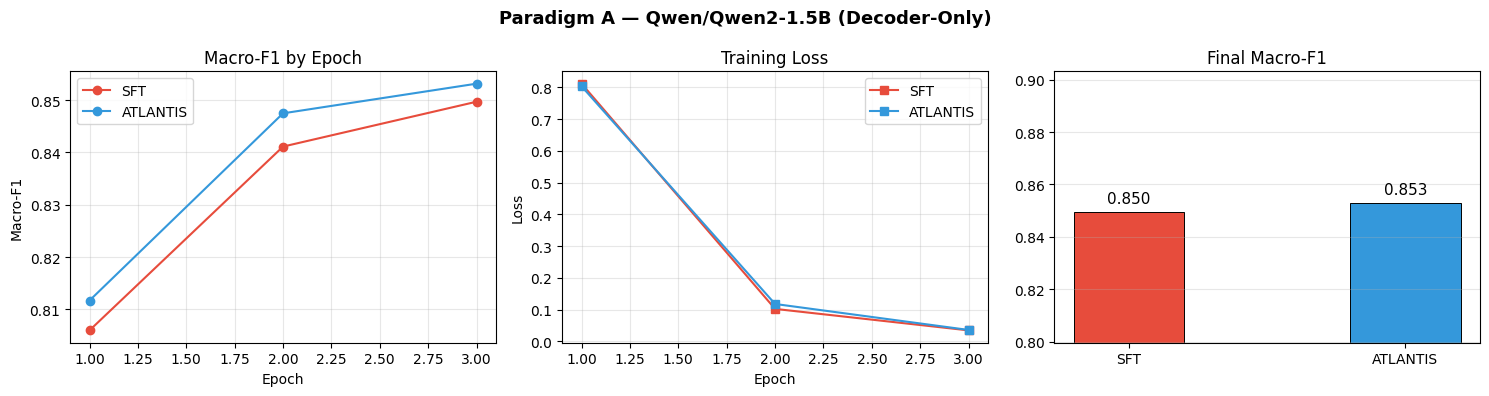

SFT:       0.8497
ATLANTIS:  0.8531
Delta:     +0.0034


In [18]:
results_A = {"SFT": hist_A_sft, "ATLANTIS": hist_A_atlantis}
COLORS_A  = {"SFT": "#e74c3c", "ATLANTIS": "#3498db"}
epochs_x  = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Paradigm A — {LARGE_MODEL} (Decoder-Only)",
             fontsize=13, fontweight="bold")

ax = axes[0]
for name, h in results_A.items():
    ax.plot(epochs_x, h["eval_f1"], marker="o", label=name, color=COLORS_A[name])
ax.set_title("Macro-F1 by Epoch"); ax.set_xlabel("Epoch"); ax.set_ylabel("Macro-F1")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for name, h in results_A.items():
    ax.plot(epochs_x, h["train_loss"], marker="s", label=name, color=COLORS_A[name])
ax.set_title("Training Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
names = list(results_A.keys())
f1s   = [results_A[n]["final_f1"] for n in names]
bars  = ax.bar(names, f1s, color=[COLORS_A[n] for n in names],
               edgecolor="black", linewidth=0.7, width=0.4)
ax.set_ylim(max(0, min(f1s) - 0.05), min(1.0, max(f1s) + 0.05))
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11)
ax.set_title("Final Macro-F1"); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("paradigm_A_qwen_results.png", dpi=150, bbox_inches="tight")
plt.show()

delta = hist_A_atlantis["final_f1"] - hist_A_sft["final_f1"]
print(f"SFT:       {hist_A_sft['final_f1']:.4f}")
print(f"ATLANTIS:  {hist_A_atlantis['final_f1']:.4f}")
print(f"Delta:     {delta:+.4f}")

---
# Part 3 — Paradigm B: LLM-Generated Weak Labels

Same structure as Flan-T5 Paradigm B.
Requires `weak_labels.json` generated by `generate_weak_labels.py`.

In [12]:
# ── Upload weak labels file from local machine ───────────────────────────────
# Supports CSV or JSON. Expected columns/keys:
#   - "sentence" or "input_text" : the raw sentence (used to align with train_all)
#   - "label" or "relation"      : integer 0-18 (SemEval label ID)
#
# If your file has different column names, update WEAK_TEXT_COL / WEAK_LABEL_COL below.

from google.colab import files
import pandas as pd
import json, os

WEAK_TEXT_COL  = "sentence"    # column containing the sentence / input text
WEAK_LABEL_COL = "label"       # column containing the integer label (0-18)

print("Upload your weak labels file (CSV or JSON)...")
uploaded = files.upload()
weak_file = list(uploaded.keys())[0]
print(f"Uploaded: {weak_file}")

# ── Load based on file extension ──────────────────────────────────────────────
ext = os.path.splitext(weak_file)[1].lower()
if ext == ".csv":
    weak_df = pd.read_csv(weak_file)
elif ext in (".json", ".jsonl"):
    try:
        weak_df = pd.read_json(weak_file)
    except ValueError:
        weak_df = pd.read_json(weak_file, lines=True)
else:
    raise ValueError(f"Unsupported file type: {ext}. Use CSV or JSON.")

print(f"Loaded {len(weak_df)} rows. Columns: {list(weak_df.columns)}")
print(weak_df.head(3))

# ── Validate columns ──────────────────────────────────────────────────────────
assert WEAK_TEXT_COL  in weak_df.columns, f"Column '{WEAK_TEXT_COL}' not found. Set WEAK_TEXT_COL."
assert WEAK_LABEL_COL in weak_df.columns, f"Column '{WEAK_LABEL_COL}' not found. Set WEAK_LABEL_COL."

# ── Convert integer labels (0-18) → canonical string labels ──────────────────
weak_df["weak_label_str"] = weak_df[WEAK_LABEL_COL].astype(int).map(semeval_label_to_str)

# Verify no unmapped labels
unmapped = weak_df["weak_label_str"].isna().sum()
assert unmapped == 0, f"{unmapped} labels could not be mapped — check values are 0-18"

# ── Accuracy vs gold if gold labels are available ─────────────────────────────
if "gold_label" in weak_df.columns:
    weak_df["gold_label_str"] = weak_df["gold_label"].astype(int).map(semeval_label_to_str)
    acc = (weak_df["weak_label_str"] == weak_df["gold_label_str"]).mean()
    print(f"\nWeak label accuracy vs gold: {acc:.1%}")
    print(f"Noise rate: {1-acc:.1%}")
else:
    print("\nNo gold_label column found — accuracy unknown.")

print(f"\nWeak label distribution:")
print(weak_df["weak_label_str"].value_counts())

Upload your weak labels file (CSV or JSON)...


Saving train_combined_numeric.csv to train_combined_numeric.csv
Uploaded: train_combined_numeric.csv
Loaded 8000 rows. Columns: ['sentence', 'label']
                                            sentence  label
0  World practices have shown that often local au...      1
1  The <e1>car kit</e1> has a GPS <e2>receiver</e...      3
2  Lollapalooza is an annual music <e1>festival</...      3

No gold_label column found — accuracy unknown.

Weak label distribution:
weak_label_str
Content-Container     4420
Cause-Effect          1753
Other                  403
Component-Whole        260
Instrument-Agency      254
Message-Topic          208
Product-Producer       204
Entity-Origin          176
Entity-Destination     173
Member-Collection      149
Name: count, dtype: int64


In [13]:
# ── Build weak_B: align uploaded weak labels with train_large examples ──────
# Matches on input_text. Weak label file may contain raw sentences — we
# reconstruct input_text using the same prompt template as load_examples().

def normalize_for_lookup(text):
    """Strip whitespace for robust matching."""
    return text.strip()

# Build lookup from sentence → weak label string
# Try matching on input_text first, fall back to raw sentence
weak_lookup = {}
for _, row in weak_df.iterrows():
    raw_text  = normalize_for_lookup(str(row[WEAK_TEXT_COL]))
    weak_label = row["weak_label_str"]

    # Build the same prompt template used in load_examples
    label_options = ", ".join(SEMEVAL_CANONICAL)
    constructed_input = (
        "Classify the semantic relation between the marked entities "
        f"in this sentence: {raw_text}\n"
        #f"Relation choices: {label_options}"
    )
    weak_lookup[normalize_for_lookup(constructed_input)] = weak_label
    # Also index by raw sentence as fallback
    weak_lookup[raw_text] = weak_label

# Align with train_large
weak_B = []
unmatched = 0
for ex in train_large:
    key = normalize_for_lookup(ex["input_text"])
    weak_label = weak_lookup.get(key)

    if weak_label is None:
        # Fallback: try matching just the sentence portion (after the prompt prefix)
        for raw_key, lbl in weak_lookup.items():
            if raw_key in key:
                weak_label = lbl
                break

    if weak_label is None:
        unmatched += 1
        continue

    weak_B.append({
        "input_text": ex["input_text"],
        "label_str":  ex["label_str"],    # gold label — used for upper-bound eval
        "weak_label": weak_label,          # GPT label — used for training
    })

print(f"Matched:   {len(weak_B)} / {len(train_large)} examples")
print(f"Unmatched: {unmatched}")

if unmatched > len(train_large) * 0.1:
    print("Warning: >10% unmatched — check that WEAK_TEXT_COL contains the raw sentences")
    print(f"  Sample train input_text: {train_large[0]['input_text'][:100]}")
    print(f"  Sample weak file text:   {weak_df[WEAK_TEXT_COL].iloc[0][:100]}")

# ── Noise rate from alignment ─────────────────────────────────────────────────
if weak_B:
    correct = sum(ex["weak_label"] == ex["label_str"] for ex in weak_B)
    print(f"\nNoise rate (matched examples): {1 - correct/len(weak_B):.1%}")
    print(f"Weak label accuracy:           {correct/len(weak_B):.1%}")

    from collections import Counter
    print("\nWeak label distribution:")
    dist = Counter(ex["weak_label"] for ex in weak_B)
    for label, count in dist.most_common():
        print(f"  {label:<25} {count:>4}  ({count/len(weak_B):.1%})")

Matched:   8000 / 8000 examples
Unmatched: 0

Noise rate (matched examples): 63.7%
Weak label accuracy:           36.3%

Weak label distribution:
  Content-Container         4420  (55.2%)
  Cause-Effect              1753  (21.9%)
  Other                      403  (5.0%)
  Component-Whole            260  (3.2%)
  Instrument-Agency          254  (3.2%)
  Message-Topic              208  (2.6%)
  Product-Producer           204  (2.5%)
  Entity-Origin              176  (2.2%)
  Entity-Destination         173  (2.2%)
  Member-Collection          149  (1.9%)


In [14]:
TARGET_NOISE_RATE = 0.20   # simulate 30% noise — tune this

def mix_labels(weak_examples, target_noise_rate):
    """Replace weak labels with gold labels to hit target noise rate.

    Current noise rate is estimated from examples that have both
    label_str (gold) and weak_label (GPT).
    """
    current_noise = sum(ex["weak_label"] != ex["label_str"] for ex in weak_examples) / len(weak_examples)
    print(f"Current noise rate:  {current_noise:.1%}")
    print(f"Target noise rate:   {target_noise_rate:.1%}")

    if target_noise_rate >= current_noise:
        print("Target >= current — no mixing needed.")
        return [dict(ex) for ex in weak_examples]

    # How many examples need to be corrected?
    n_total      = len(weak_examples)
    n_noisy      = int(current_noise * n_total)      # currently wrong
    n_target_noisy = int(target_noise_rate * n_total) # want this many wrong
    n_to_fix     = n_noisy - n_target_noisy

    print(f"Correcting {n_to_fix} examples (replacing weak label with gold)...")

    # Find currently wrong examples and randomly fix n_to_fix of them
    wrong_idx = [i for i, ex in enumerate(weak_examples) if ex["weak_label"] != ex["label_str"]]
    fix_idx   = set(random.sample(wrong_idx, n_to_fix))

    mixed = []
    for i, ex in enumerate(weak_examples):
        ex_copy = dict(ex)
        if i in fix_idx:
            ex_copy["weak_label"] = ex_copy["label_str"]   # replace with gold
        mixed.append(ex_copy)

    # Verify
    actual_noise = sum(ex["weak_label"] != ex["label_str"] for ex in mixed) / len(mixed)
    print(f"Actual noise after mixing: {actual_noise:.1%}")
    return mixed

# Generate mixed datasets at different noise rates for ablation
noise_rates  = [0.10, 0.20, 0.30, 0.40, 0.50]
mixed_by_noise = {r: mix_labels(weak_B, r) for r in noise_rates}

# Use one for Paradigm B experiments
weak_B_mixed = mixed_by_noise[TARGET_NOISE_RATE]
print(f"\nUsing weak_B_mixed with {TARGET_NOISE_RATE:.0%} noise for Paradigm B.")

Current noise rate:  63.7%
Target noise rate:   10.0%
Correcting 4298 examples (replacing weak label with gold)...
Actual noise after mixing: 10.0%
Current noise rate:  63.7%
Target noise rate:   20.0%
Correcting 3498 examples (replacing weak label with gold)...
Actual noise after mixing: 20.0%
Current noise rate:  63.7%
Target noise rate:   30.0%
Correcting 2698 examples (replacing weak label with gold)...
Actual noise after mixing: 30.0%
Current noise rate:  63.7%
Target noise rate:   40.0%
Correcting 1898 examples (replacing weak label with gold)...
Actual noise after mixing: 40.0%
Current noise rate:  63.7%
Target noise rate:   50.0%
Correcting 1098 examples (replacing weak label with gold)...
Actual noise after mixing: 50.0%

Using weak_B_mixed with 20% noise for Paradigm B.


In [15]:
p_r_B = finetune_small_model(weak_B_mixed, tag="p_r_B (GPT-labeled)", label_source="weak")

_, test_loader_pr_B = make_loaders(test_examples, label_source="gold")
f1_pr_B, _, _ = evaluate(p_r_B, test_loader_pr_B)
print(f"p_r_B test F1: {f1_pr_B:.4f}")


Fine-tuning p_r_B (GPT-labeled) (Qwen/Qwen2-1.5B) for 2 epochs...
  Effective batch: 1 x 16 = 16
Loading Qwen/Qwen2-1.5B...


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

  Parameters: 1.54B
  VRAM after load: 3.09 GB


...

  Epoch 1  loss=0.8778


  p_r_B (GPT-labeled) epoch 2/2:   0%|          | 0/8000 [00:00<?, ?it/s]

  Epoch 2  loss=0.2285
p_r_B (GPT-labeled) complete.


Eval:   0%|          | 0/2717 [00:00<?, ?it/s]

Label-snapping stats:
  exact         2717  (100.0%)
  substring        0  (0.0%)
  logprob          0  (0.0%)
p_r_B test F1: 0.8314


In [16]:
p_s_b_B        = load_frozen_small_model()
p_l_b_frozen_B = load_frozen_large_model()

for ex in tqdm(weak_B_mixed, desc="Computing log-probs"):
    ex["log_pr"]   = compute_seq_logprob(p_r_B,          ex["input_text"], ex["weak_label"])
    ex["log_ps_b"] = compute_seq_logprob(p_s_b_B,        ex["input_text"], ex["weak_label"])
    ex["log_pl_b"] = compute_seq_logprob(p_l_b_frozen_B, ex["input_text"], ex["weak_label"])
    ex["influence_ratio"] = ex["log_pr"] - ex["log_ps_b"]

weights = compute_and_normalize_weights(weak_B_mixed)

print(f"Normalized weight mean: {weights.mean():.4f}")
print(f"Normalized weight std:  {weights.std():.4f}")
print(f"Normalized weight min:  {weights.min():.4f}")
print(f"Normalized weight max:  {weights.max():.4f}")

by_label = {}
for ex in weak_B_mixed:
    by_label.setdefault(ex["label_str"], []).append(ex["weight"])
print("\nMean weight by relation type:")
for l, ws in sorted(by_label.items(), key=lambda x: -np.mean(x[1])):
    print(f"  {l:<25} mean={np.mean(ws):.3f}  std={np.std(ws):.3f}  n={len(ws)}")

Loading p^S_b: Qwen/Qwen2-1.5B (frozen)
Loading Qwen/Qwen2-1.5B...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  Parameters: 1.54B
  VRAM after load: 6.20 GB
Loading p^L_b: Qwen/Qwen2-7B (frozen, pre-computation only)
Loading Qwen/Qwen2-7B...


config.json:   0%|          | 0.00/664 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

  Parameters: 7.62B
  VRAM after load: 21.46 GB


Computing log-probs:   0%|          | 0/8000 [00:00<?, ?it/s]

Normalized weight mean: 1.0000
Normalized weight std:  3.0428
Normalized weight min:  0.0079
Normalized weight max:  12.9846

Mean weight by relation type:
  Content-Container         mean=8.979  std=4.973  n=540
  Message-Topic             mean=2.275  std=3.941  n=634
  Entity-Destination        mean=0.566  std=2.175  n=845
  Instrument-Agency         mean=0.484  std=1.700  n=504
  Component-Whole           mean=0.355  std=1.600  n=941
  Entity-Origin             mean=0.255  std=1.342  n=716
  Other                     mean=0.189  std=1.077  n=1410
  Product-Producer          mean=0.163  std=0.876  n=717
  Member-Collection         mean=0.092  std=0.277  n=690
  Cause-Effect              mean=0.023  std=0.158  n=1003


In [17]:
del p_r_B, p_s_b_B, p_l_b_frozen_B
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"VRAM after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB")

VRAM after cleanup: 0.02 GB


In [18]:
hist_B_uniform, model_B_uniform = train_large_model(
    weak_B_mixed, label_source="weak", include_weights=False, loss_mode="sft",
    tag="Paradigm B — Uniform (GPT labels, w=1)",
)


  Paradigm B — Uniform (GPT labels, w=1)
  Effective batch: 1 x 16 = 16
Loading Qwen/Qwen2-7B...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  Parameters: 7.62B
  VRAM after load: 15.29 GB


Epoch 1/2:   0%|          | 0/8000 [00:00<?, ?it/s]

Eval:   0%|          | 0/2717 [00:00<?, ?it/s]

Label-snapping stats:
  exact         2717  (100.0%)
  substring        0  (0.0%)
  logprob          0  (0.0%)
  Epoch 1  loss=0.5856  macro-F1=0.8403


Epoch 2/2:   0%|          | 0/8000 [00:00<?, ?it/s]

Eval:   0%|          | 0/2717 [00:00<?, ?it/s]

Label-snapping stats:
  exact         2717  (100.0%)
  substring        0  (0.0%)
  logprob          0  (0.0%)
  Epoch 2  loss=0.1932  macro-F1=0.8537
  -> Final F1: 0.8537


In [ ]:
del model_B_uniform; torch.cuda.empty_cache()

hist_B_atlantis, model_B_atlantis = train_large_model(
    weak_B_mixed, label_source="weak", include_weights=True, loss_mode="atlantis",
    tag="Paradigm B — ATLANTIS (GPT labels, weighted CE)",
)


  Paradigm B — ATLANTIS (GPT labels, weighted CE)
  Effective batch: 1 x 16 = 16
Loading Qwen/Qwen2-7B...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  Parameters: 7.62B
  VRAM after load: 15.29 GB


Epoch 1/2:   0%|          | 0/8000 [00:00<?, ?it/s]

Eval:   0%|          | 0/2717 [00:00<?, ?it/s]

Label-snapping stats:
  exact         2717  (100.0%)
  substring        0  (0.0%)
  logprob          0  (0.0%)
  Epoch 1  loss=0.2207  macro-F1=0.3959  w_mean=1.000  w_std=3.043


Epoch 2/2:   0%|          | 0/8000 [00:00<?, ?it/s]

In [ ]:
results_B = {"uniform": hist_B_uniform, "atlantis": hist_B_atlantis}
COLORS_B  = {"uniform": "#e74c3c", "atlantis": "#3498db"}
epochs_x  = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Paradigm B — {LARGE_MODEL} + GPT Weak Labels",
             fontsize=13, fontweight="bold")

ax = axes[0]
for name, h in results_B.items():
    ax.plot(epochs_x, h["eval_f1"], marker="o", label=name, color=COLORS_B[name])
ax.set_title("Macro-F1 by Epoch"); ax.set_xlabel("Epoch"); ax.set_ylabel("Macro-F1")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for name, h in results_B.items():
    ax.plot(epochs_x, h["train_loss"], marker="s", label=name, color=COLORS_B[name])
ax.set_title("Training Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
names_b = list(results_B.keys())
f1s_b   = [results_B[n]["final_f1"] for n in names_b]
bars    = ax.bar(names_b, f1s_b, color=[COLORS_B[n] for n in names_b],
                 edgecolor="black", linewidth=0.7)
ax.set_ylim(max(0, min(f1s_b) - 0.05), min(1.0, max(f1s_b) + 0.05))
for bar, val in zip(bars, f1s_b):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_title("Final Macro-F1"); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("paradigm_B_qwen_results.png", dpi=150, bbox_inches="tight")
plt.show()

f1_uniform  = hist_B_uniform["final_f1"]
f1_atlantis = hist_B_atlantis["final_f1"]

print(f"\n{'Condition':<12} {'F1':>8}")
print("-" * 22)
for name in ["uniform", "atlantis"]:
    print(f"{name:<12} {results_B[name]['final_f1']:>8.4f}")
print()
print(f"ATLANTIS improvement:        {gap_recovered:+.4f}")

In [46]:
del model_B_atlantis; torch.cuda.empty_cache()

NameError: name 'model_B_atlantis' is not defined

In [11]:
correct = sum(ex["weak_label"] == ex["label_str"] for ex in weak_B_mixed)
print(f"Noise rate: {1 - correct/len(weak_B_mixed):.1%}")

# Check weight distribution first
weights = np.array([ex["weight"] for ex in weak_B_mixed])
print(f"\nWeight distribution:")
print(f"  mean={weights.mean():.3f}  std={weights.std():.3f}")
print(f"  min={weights.min():.3f}   max={weights.max():.3f}")
for pct in [10, 25, 50, 75, 90]:
    print(f"  p{pct}={np.percentile(weights, pct):.3f}")

# Use percentile-based thresholds instead of fixed values
high_thresh = np.percentile(weights, 75)
low_thresh  = np.percentile(weights, 25)

high_w = [ex for ex in weak_B_mixed if ex["weight"] >= high_thresh]
low_w  = [ex for ex in weak_B_mixed if ex["weight"] <= low_thresh]

high_acc = sum(ex["weak_label"] == ex["label_str"] for ex in high_w) / len(high_w)
low_acc  = sum(ex["weak_label"] == ex["label_str"] for ex in low_w)  / len(low_w)
print(f"\nHigh-weight (top 25%, w>={high_thresh:.2f}) accuracy: {high_acc:.1%}  (n={len(high_w)})")
print(f"Low-weight  (bot 25%, w<={low_thresh:.2f}) accuracy: {low_acc:.1%}  (n={len(low_w)})")
print(f"\nDelta: {high_acc - low_acc:+.1%}  (positive = weights correlate with quality)")

NameError: name 'weak_B_mixed' is not defined